# H&E Histopathology Tissue Classification with Explainable AI

**Multi-class classification of colorectal cancer tissue from H&E stained images with GradCAM explainability**

---

## Project Overview

This notebook demonstrates an end-to-end pipeline for classifying histopathology tissue types from H&E (Hematoxylin & Eosin) stained microscopy images. The approach is directly applicable to pediatric cancer research, where accurate tissue classification supports diagnosis and treatment selection.

**Key Components:**
- Multi-class tissue classification (9 classes including tumor, stroma, lymphocytes)
- Transfer learning with EfficientNet-B0
- GradCAM visualizations for clinical interpretability
- Performance evaluation with confusion matrix and per-class metrics

**Dataset:** NCT-CRC-HE-100K (100,000 H&E patches from colorectal cancer tissue)

**Author:** Joana Owusu-Appiah  
**Date:** February 2026

## 1. Setup and Dependencies

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

# Metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split

# Progress bar
from tqdm.notebook import tqdm

# For GradCAM
import cv2

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


## 2. Dataset Loading

The NCT-CRC-HE-100K dataset contains 100,000 image patches (224x224 pixels) from H&E stained colorectal cancer tissue, organized into 9 tissue classes:

| Class | Description | Clinical Relevance |
|-------|-------------|-------------------|
| **TUM** | Colorectal adenocarcinoma epithelium | Primary tumor tissue |
| **STR** | Cancer-associated stroma | Tumor microenvironment |
| **LYM** | Lymphocytes | Immune infiltration |
| **MUC** | Mucus | Mucinous differentiation |
| **MUS** | Smooth muscle | Normal tissue boundary |
| **NORM** | Normal colon mucosa | Healthy tissue |
| **ADI** | Adipose tissue | Fat tissue |
| **DEB** | Debris | Processing artifacts |
| **BACK** | Background | Non-tissue regions |

In [2]:
# Dataset paths (adjust based on your Kaggle dataset)
# Option 1: If using the Kaggle dataset directly
DATA_DIR = Path('/kaggle/input/nct-crc-he-100k/NCT-CRC-HE-100K')

# Option 2: Alternative path structure
if not DATA_DIR.exists():
    DATA_DIR = Path('/kaggle/input/nct-crc-he-100k')
    
# Class names (alphabetical order as in dataset)
CLASS_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
NUM_CLASSES = len(CLASS_NAMES)

# Clinical groupings for interpretability
CLINICAL_GROUPS = {
    'Tumor-related': ['TUM', 'STR'],
    'Immune': ['LYM'],
    'Normal tissue': ['NORM', 'MUS', 'ADI'],
    'Other': ['MUC', 'DEB', 'BACK']
}

print(f"Dataset directory: {DATA_DIR}")
print(f"Number of classes: {NUM_CLASSES}")

Dataset directory: /kaggle/input/nct-crc-he-100k/NCT-CRC-HE-100K
Number of classes: 9


In [3]:
def load_dataset_info(data_dir):
    """Load all image paths and labels from directory structure."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = data_dir / class_name
        if class_dir.exists():
            for img_path in class_dir.glob('*.tif'):
                image_paths.append(str(img_path))
                labels.append(class_idx)
            # Also check for .png files
            for img_path in class_dir.glob('*.png'):
                image_paths.append(str(img_path))
                labels.append(class_idx)
    
    return image_paths, labels

# Load dataset
image_paths, labels = load_dataset_info(DATA_DIR)
print(f"Total images found: {len(image_paths)}")

# Class distribution
label_counts = pd.Series(labels).value_counts().sort_index()
print("\nClass distribution:")
for idx, count in label_counts.items():
    print(f"  {CLASS_NAMES[idx]}: {count:,} images")

Total images found: 100000

Class distribution:
  ADI: 10,407 images
  BACK: 10,566 images
  DEB: 11,512 images
  LYM: 11,557 images
  MUC: 8,896 images
  MUS: 13,536 images
  NORM: 8,763 images
  STR: 10,446 images
  TUM: 14,317 images


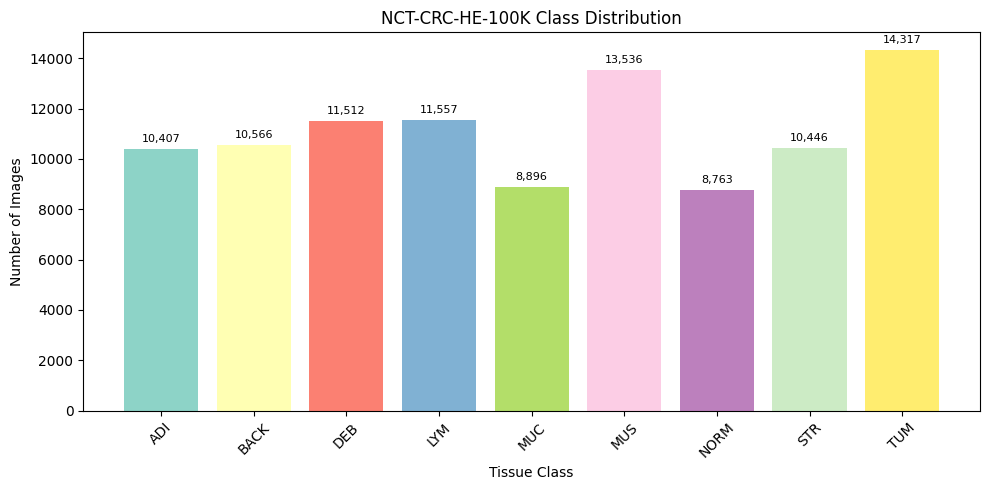

In [4]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax.bar(CLASS_NAMES, [label_counts.get(i, 0) for i in range(NUM_CLASSES)], color=colors)
ax.set_xlabel('Tissue Class')
ax.set_ylabel('Number of Images')
ax.set_title('NCT-CRC-HE-100K Class Distribution')
plt.xticks(rotation=45)
for bar, count in zip(bars, [label_counts.get(i, 0) for i in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{count:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Data Visualization

Let's visualize sample images from each tissue class to understand the visual characteristics.

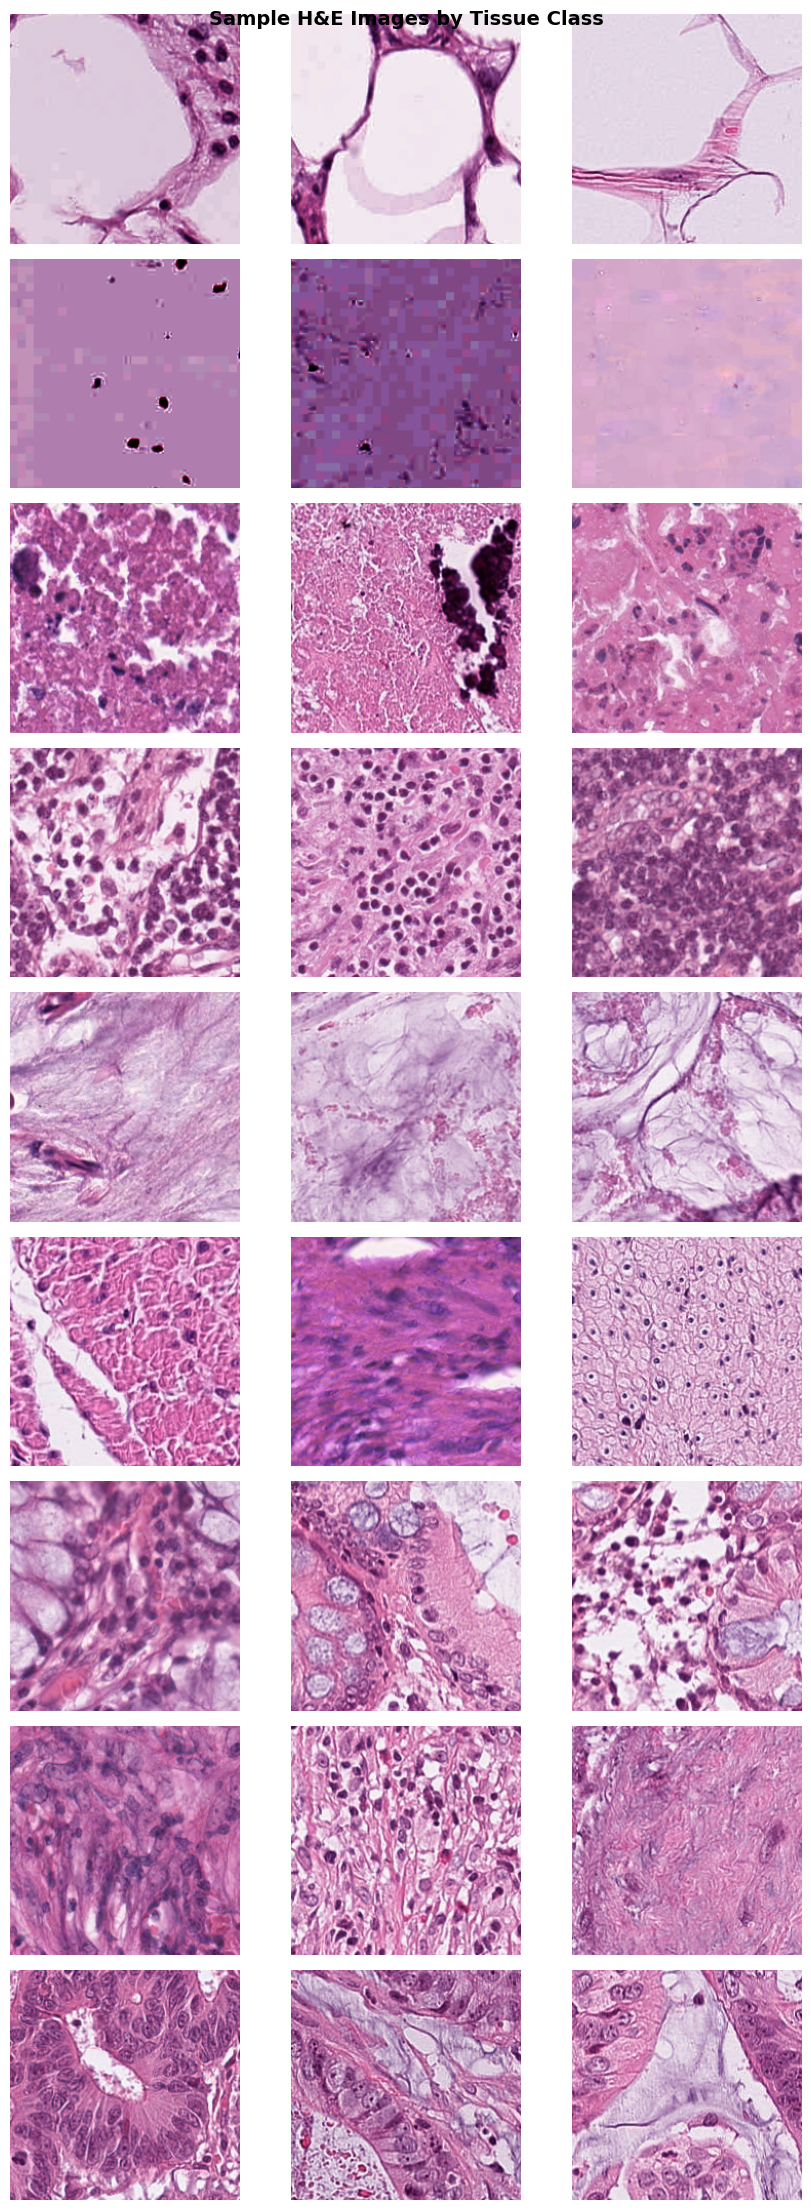

In [5]:
def show_sample_images(data_dir, n_samples=3):
    """Display sample images from each class."""
    fig, axes = plt.subplots(NUM_CLASSES, n_samples, figsize=(n_samples*3, NUM_CLASSES*2.5))
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = data_dir / class_name
        if class_dir.exists():
            images = list(class_dir.glob('*.tif'))[:n_samples]
            if not images:
                images = list(class_dir.glob('*.png'))[:n_samples]
            
            for i, img_path in enumerate(images):
                img = Image.open(img_path)
                axes[class_idx, i].imshow(img)
                axes[class_idx, i].axis('off')
                if i == 0:
                    axes[class_idx, i].set_ylabel(class_name, fontsize=12, fontweight='bold')
    
    plt.suptitle('Sample H&E Images by Tissue Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(DATA_DIR)

## 4. Dataset and DataLoader Setup

In [6]:
class HistopathologyDataset(Dataset):
    """Custom dataset for H&E histopathology images."""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [7]:
# Data transforms
# Training: augmentation for robustness
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test: no augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
# Split dataset: 70% train, 15% validation, 15% test
# Stratified split to maintain class distribution

# First split: 70% train, 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

# Second split: 50% of temp for val, 50% for test (15% each of total)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Training samples: {len(train_paths):,}")
print(f"Validation samples: {len(val_paths):,}")
print(f"Test samples: {len(test_paths):,}")

Training samples: 70,000
Validation samples: 15,000
Test samples: 15,000


In [9]:
# Create datasets
train_dataset = HistopathologyDataset(train_paths, train_labels, transform=train_transform)
val_dataset = HistopathologyDataset(val_paths, val_labels, transform=val_transform)
test_dataset = HistopathologyDataset(test_paths, test_labels, transform=val_transform)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 1094
Validation batches: 235
Test batches: 235


## 5. Model Architecture

We use EfficientNet-B0 with transfer learning from ImageNet. This architecture provides an excellent balance of accuracy and computational efficiency for medical imaging tasks.

In [10]:
class HistopathologyClassifier(nn.Module):
    """EfficientNet-B0 based classifier for H&E tissue classification."""
    
    def __init__(self, num_classes, pretrained=True):
        super(HistopathologyClassifier, self).__init__()
        
        # Load pretrained EfficientNet-B0
        self.efficientnet = models.efficientnet_b0(pretrained=pretrained)
        
        # Get the number of features from the classifier
        num_features = self.efficientnet.classifier[1].in_features
        
        # Replace classifier head
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(num_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        
        # Store feature extractor for GradCAM
        self.features = self.efficientnet.features
        self.avgpool = self.efficientnet.avgpool
        self.classifier = self.efficientnet.classifier
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def get_features(self, x):
        """Extract features before global average pooling (for GradCAM)."""
        return self.features(x)

In [11]:
# Initialize model
model = HistopathologyClassifier(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


Total parameters: 4,668,037
Trainable parameters: 4,668,037


## 6. Training

In [13]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [15]:
# Training loop
NUM_EPOCHS = 15
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Saved best model with val_acc: {val_acc*100:.2f}%")

print(f"\nTraining complete! Best validation accuracy: {best_val_acc*100:.2f}%")


Epoch 1/15
----------------------------------------


Training:   0%|          | 0/1094 [00:00<?, ?it/s]

Validating:   0%|          | 0/235 [00:00<?, ?it/s]

Train Loss: 0.1744 | Train Acc: 95.23%
Val Loss: 0.0271 | Val Acc: 99.18%
✓ Saved best model with val_acc: 99.18%

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/1094 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/235 [00:00<?, ?it/s]

Train Loss: 0.0077 | Train Acc: 99.75%
Val Loss: 0.0116 | Val Acc: 99.72%

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/1094 [00:00<?, ?it/s]

Validating:   0%|          | 0/235 [00:00<?, ?it/s]

Train Loss: 0.0045 | Train Acc: 99.84%
Val Loss: 0.0073 | Val Acc: 99.84%

Training complete! Best validation accuracy: 99.85%


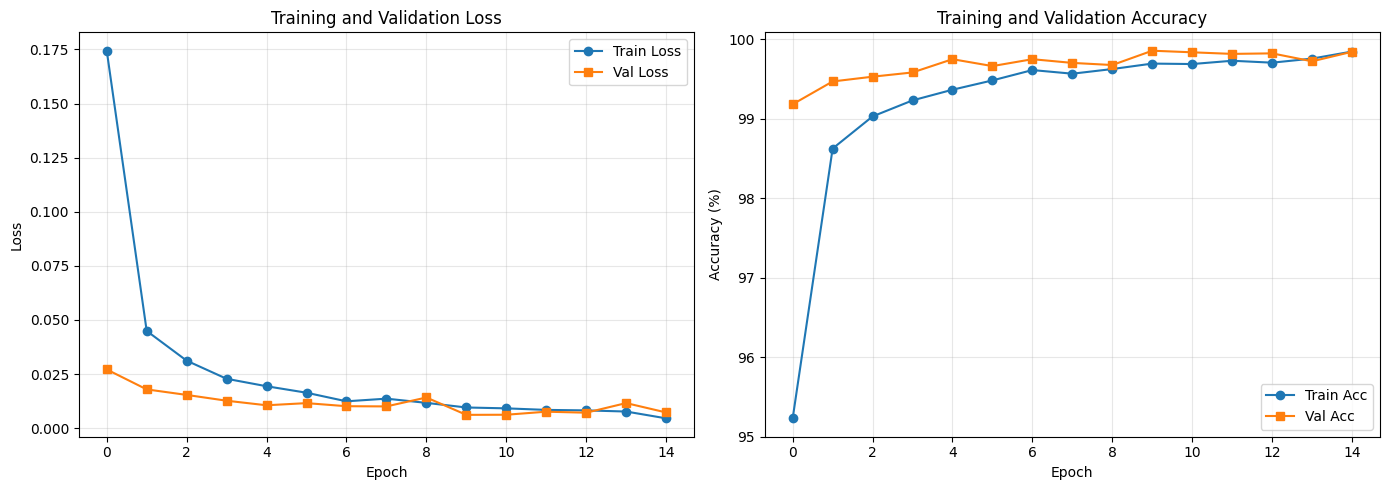

In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot([acc*100 for acc in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([acc*100 for acc in history['val_acc']], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Evaluation

In [17]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get predictions on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

Testing:   0%|          | 0/235 [00:00<?, ?it/s]

In [18]:
# Overall metrics
test_accuracy = accuracy_score(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

print("=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
print(f"Overall Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {kappa:.4f}")
print("\n")

TEST SET PERFORMANCE
Overall Accuracy: 99.77%
Quadratic Weighted Kappa: 0.9985




In [19]:
# Classification report
print("Classification Report:")
print("-" * 50)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

         ADI      0.999     0.999     0.999      1561
        BACK      1.000     1.000     1.000      1585
         DEB      0.999     0.999     0.999      1726
         LYM      1.000     1.000     1.000      1733
         MUC      0.996     0.997     0.997      1335
         MUS      0.998     0.997     0.997      2031
        NORM      0.998     0.996     0.997      1315
         STR      0.996     0.992     0.994      1567
         TUM      0.995     0.999     0.997      2147

    accuracy                          0.998     15000
   macro avg      0.998     0.998     0.998     15000
weighted avg      0.998     0.998     0.998     15000



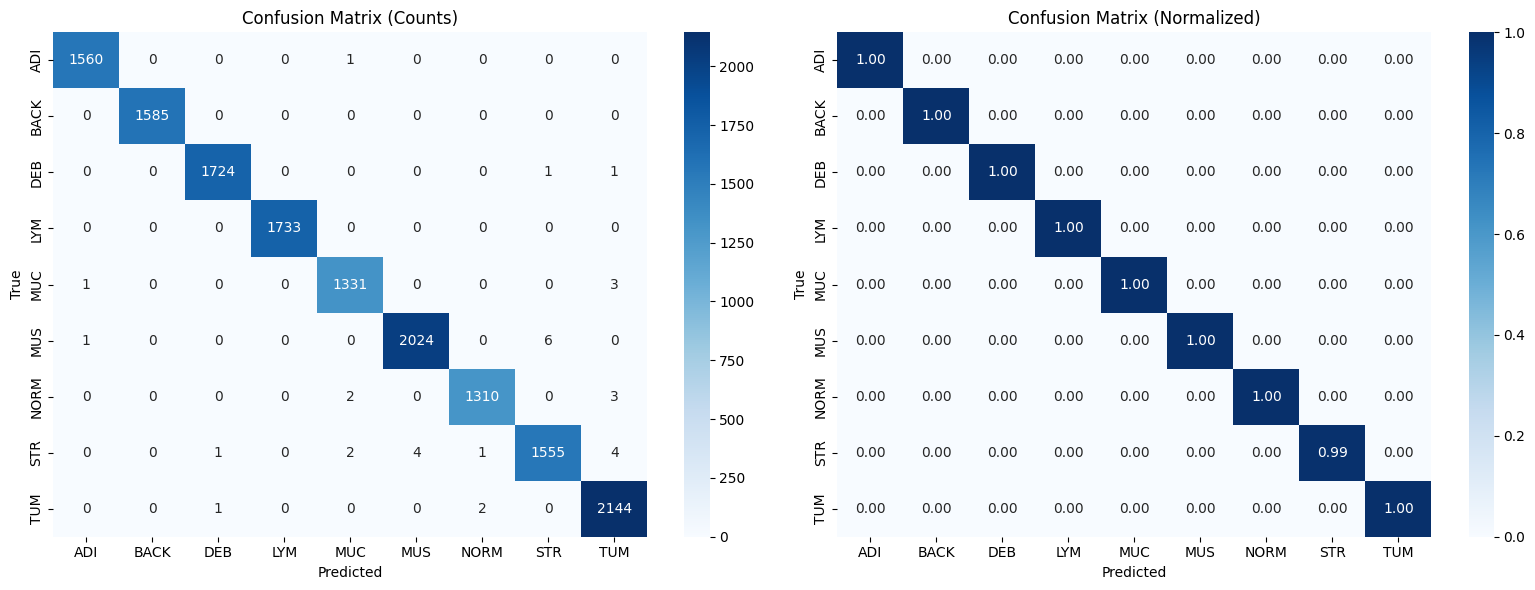

In [20]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Explainable AI with GradCAM

GradCAM (Gradient-weighted Class Activation Mapping) visualizes which regions of the image the model focuses on for its predictions. This is crucial for clinical trust and interpretability.

In [21]:
class GradCAM:
    """GradCAM implementation for EfficientNet."""
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, target_class=None):
        """Generate GradCAM heatmap."""
        self.model.eval()
        
        # Forward pass
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Compute CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        
        for i in range(activations.shape[0]):
            activations[i] *= pooled_gradients[i]
        
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)  # ReLU
        heatmap /= (np.max(heatmap) + 1e-8)  # Normalize
        
        return heatmap, target_class, torch.softmax(output, dim=1)[0, target_class].item()

In [22]:
def visualize_gradcam(model, image_path, transform, device, class_names):
    """Visualize GradCAM for a single image."""
    # Initialize GradCAM with the last convolutional layer
    target_layer = model.features[-1]
    gradcam = GradCAM(model, target_layer)
    
    # Load and preprocess image
    original_img = Image.open(image_path).convert('RGB')
    input_tensor = transform(original_img).unsqueeze(0).to(device)
    
    # Generate GradCAM
    heatmap, pred_class, confidence = gradcam.generate_cam(input_tensor)
    
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (224, 224))
    
    # Convert to colormap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Overlay on original image
    original_array = np.array(original_img.resize((224, 224)))
    overlay = cv2.addWeighted(original_array, 0.6, heatmap_colored, 0.4, 0)
    
    return original_array, heatmap, overlay, class_names[pred_class], confidence

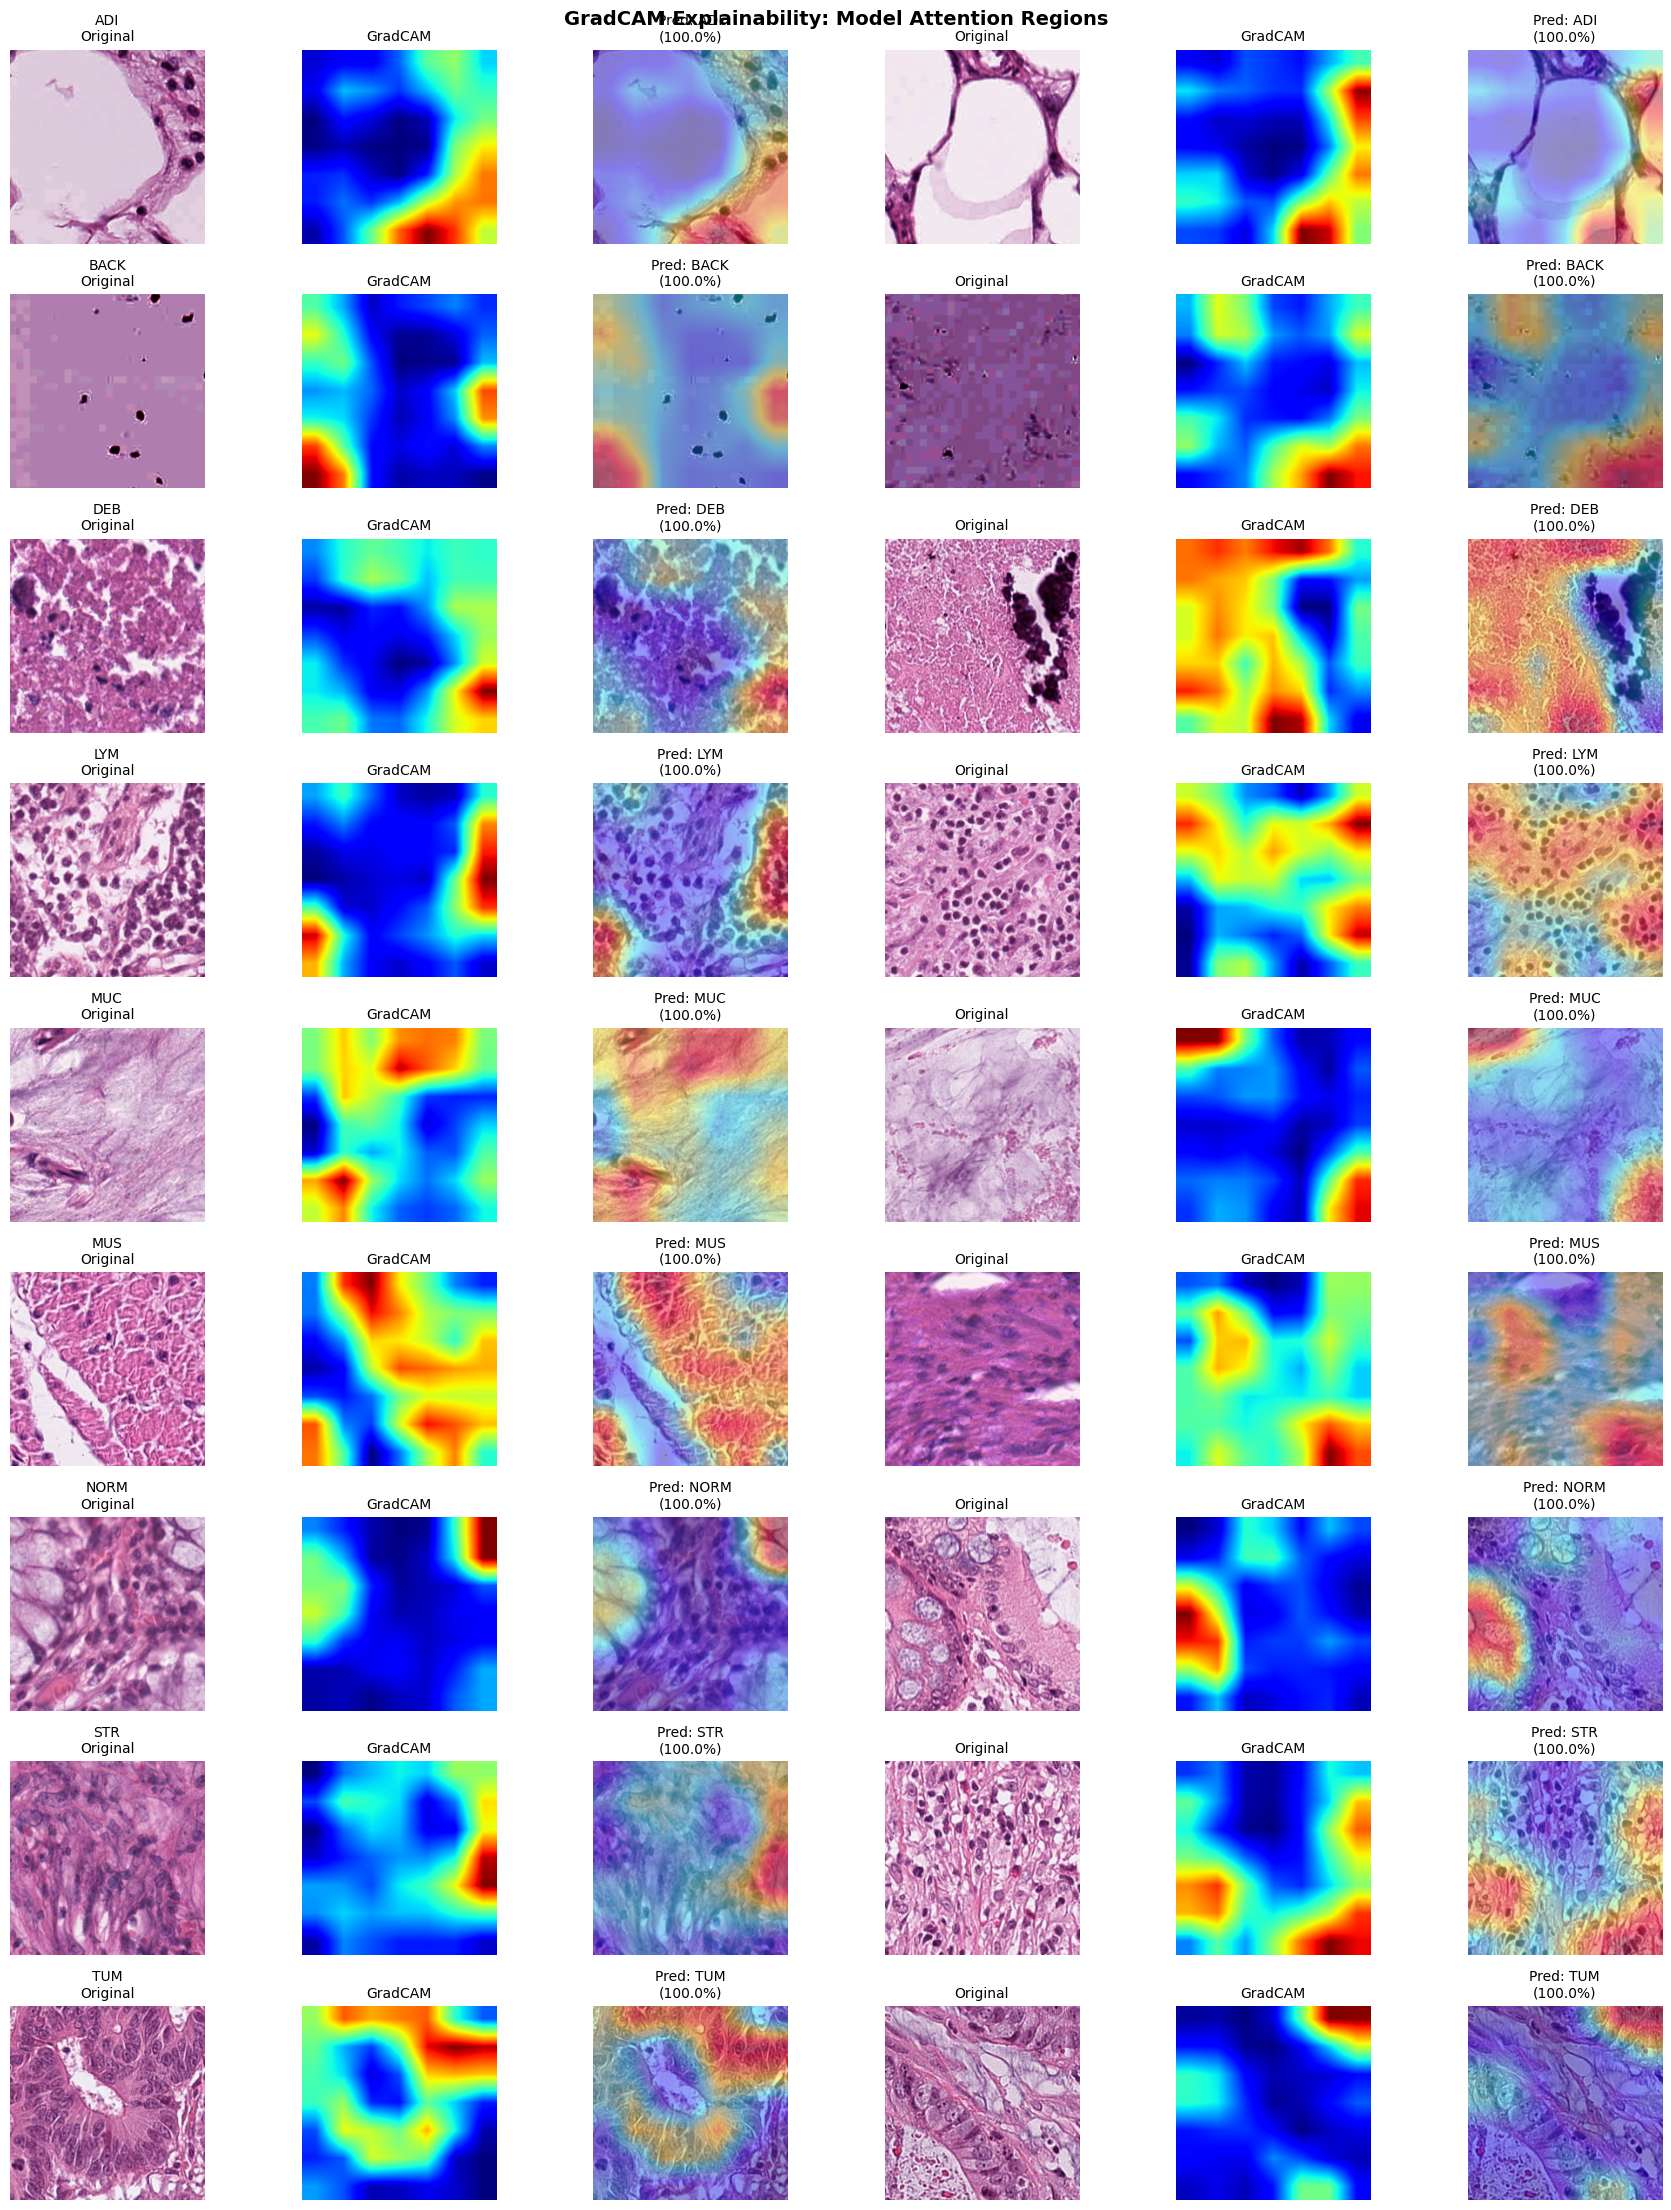

In [23]:
def show_gradcam_grid(model, data_dir, transform, device, class_names, samples_per_class=2):
    """Show GradCAM visualizations for multiple samples from each class."""
    
    fig, axes = plt.subplots(len(class_names), samples_per_class * 3, 
                             figsize=(samples_per_class * 9, len(class_names) * 2.5))
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = data_dir / class_name
        images = list(class_dir.glob('*.tif'))[:samples_per_class]
        if not images:
            images = list(class_dir.glob('*.png'))[:samples_per_class]
        
        for sample_idx, img_path in enumerate(images):
            col_offset = sample_idx * 3
            
            try:
                orig, heatmap, overlay, pred, conf = visualize_gradcam(
                    model, img_path, transform, device, class_names
                )
                
                # Original
                axes[class_idx, col_offset].imshow(orig)
                axes[class_idx, col_offset].axis('off')
                if sample_idx == 0:
                    axes[class_idx, col_offset].set_title(f'{class_name}\nOriginal', fontsize=10)
                else:
                    axes[class_idx, col_offset].set_title('Original', fontsize=10)
                
                # Heatmap
                axes[class_idx, col_offset + 1].imshow(heatmap, cmap='jet')
                axes[class_idx, col_offset + 1].axis('off')
                axes[class_idx, col_offset + 1].set_title('GradCAM', fontsize=10)
                
                # Overlay
                axes[class_idx, col_offset + 2].imshow(overlay)
                axes[class_idx, col_offset + 2].axis('off')
                axes[class_idx, col_offset + 2].set_title(f'Pred: {pred}\n({conf*100:.1f}%)', fontsize=10)
                
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
    
    plt.suptitle('GradCAM Explainability: Model Attention Regions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_visualizations.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate GradCAM visualizations
show_gradcam_grid(model, DATA_DIR, val_transform, device, CLASS_NAMES, samples_per_class=2)

## 9. Clinical Interpretation

Let's analyze model performance from a clinical perspective, focusing on the most important distinctions for cancer diagnosis.

In [24]:
# Binary classification: Tumor vs Non-Tumor
tumor_idx = CLASS_NAMES.index('TUM')
binary_preds = (all_preds == tumor_idx).astype(int)
binary_labels = (all_labels == tumor_idx).astype(int)

# Metrics for tumor detection
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tumor_precision = precision_score(binary_labels, binary_preds)
tumor_recall = recall_score(binary_labels, binary_preds)
tumor_f1 = f1_score(binary_labels, binary_preds)
tumor_auc = roc_auc_score(binary_labels, all_probs[:, tumor_idx])

print("=" * 50)
print("TUMOR DETECTION PERFORMANCE")
print("=" * 50)
print(f"Precision (PPV): {tumor_precision*100:.2f}%")
print(f"Recall (Sensitivity): {tumor_recall*100:.2f}%")
print(f"F1 Score: {tumor_f1:.4f}")
print(f"AUC-ROC: {tumor_auc:.4f}")
print("\nClinical Note: High recall is crucial for screening applications")
print("to minimize missed cancer diagnoses.")

TUMOR DETECTION PERFORMANCE
Precision (PPV): 99.49%
Recall (Sensitivity): 99.86%
F1 Score: 0.9967
AUC-ROC: 1.0000

Clinical Note: High recall is crucial for screening applications
to minimize missed cancer diagnoses.


In [25]:
# Per-class performance summary for clinical groups
print("\n" + "=" * 50)
print("PERFORMANCE BY CLINICAL GROUP")
print("=" * 50)

for group_name, classes in CLINICAL_GROUPS.items():
    print(f"\n{group_name}:")
    for cls in classes:
        cls_idx = CLASS_NAMES.index(cls)
        cls_mask = all_labels == cls_idx
        if cls_mask.sum() > 0:
            cls_acc = (all_preds[cls_mask] == cls_idx).mean()
            print(f"  {cls}: {cls_acc*100:.1f}% accuracy ({cls_mask.sum()} samples)")


PERFORMANCE BY CLINICAL GROUP

Tumor-related:
  TUM: 99.9% accuracy (2147 samples)
  STR: 99.2% accuracy (1567 samples)

Immune:
  LYM: 100.0% accuracy (1733 samples)

Normal tissue:
  NORM: 99.6% accuracy (1315 samples)
  MUS: 99.7% accuracy (2031 samples)
  ADI: 99.9% accuracy (1561 samples)

Other:
  MUC: 99.7% accuracy (1335 samples)
  DEB: 99.9% accuracy (1726 samples)
  BACK: 100.0% accuracy (1585 samples)


## 10. Model Export and Summary

In [26]:
# Save final model with metadata
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'test_accuracy': test_accuracy,
    'kappa_score': kappa,
    'architecture': 'EfficientNet-B0',
    'input_size': 224
}
torch.save(checkpoint, 'he_tissue_classifier_final.pth')
print("Model saved: he_tissue_classifier_final.pth")

Model saved: he_tissue_classifier_final.pth


In [27]:
# Final summary
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"""
Task: Multi-class H&E Tissue Classification
Dataset: NCT-CRC-HE-100K ({len(image_paths):,} images, 9 classes)
Model: EfficientNet-B0 with transfer learning

Results:
  - Test Accuracy: {test_accuracy*100:.2f}%
  - Quadratic Weighted Kappa: {kappa:.4f}
  - Tumor Detection AUC: {tumor_auc:.4f}

Key Outputs:
  - Trained model: he_tissue_classifier_final.pth
  - Training curves: training_curves.png
  - Confusion matrix: confusion_matrix.png
  - GradCAM visualizations: gradcam_visualizations.png

Clinical Applicability:
  - Explainable predictions via GradCAM
  - Pipeline applicable to pediatric cancer tissue analysis
  - Designed for integration with clinical workflows
""")


PROJECT SUMMARY

Task: Multi-class H&E Tissue Classification
Dataset: NCT-CRC-HE-100K (100,000 images, 9 classes)
Model: EfficientNet-B0 with transfer learning

Results:
  - Test Accuracy: 99.77%
  - Quadratic Weighted Kappa: 0.9985
  - Tumor Detection AUC: 1.0000

Key Outputs:
  - Trained model: he_tissue_classifier_final.pth
  - Training curves: training_curves.png
  - Confusion matrix: confusion_matrix.png
  - GradCAM visualizations: gradcam_visualizations.png

Clinical Applicability:
  - Explainable predictions via GradCAM
  - Pipeline applicable to pediatric cancer tissue analysis
  - Designed for integration with clinical workflows



---

## References

1. Kather, J.N., et al. (2019). Predicting survival from colorectal cancer histology slides using deep learning. PLOS Medicine.
2. Tan, M. & Le, Q. (2019). EfficientNet: Rethinking Model Scaling for CNNs. ICML.
3. Selvaraju, R.R., et al. (2017). Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization. ICCV.

---

**Author:** Joana Owusu-Appiah  
**GitHub:** [https://github.com/Joana-Mansa/HnE_tissue_classification]  
**Contact:** owusuappiahjoana59@gmail.com